In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# dataset creation for outlier
np.random.seed(42)
normal_data=np.random.normal(50,10,100)
outlier=[150,200,250]

In [4]:
data=np.concatenate([normal_data,outlier])
df=pd.DataFrame({"value":data})
print(df)
print(df.describe())

          value
0     54.967142
1     48.617357
2     56.476885
3     65.230299
4     47.658466
..          ...
98    50.051135
99    47.654129
100  150.000000
101  200.000000
102  250.000000

[103 rows x 1 columns]
            value
count  103.000000
mean    53.360713
std     27.937209
min     23.802549
25%     44.185369
50%     49.279899
75%     55.279137
max    250.000000


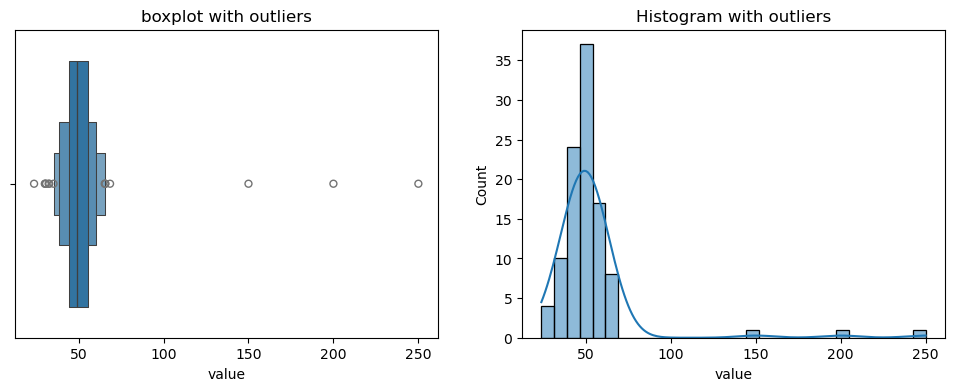

In [5]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxenplot(x=df['value'])
plt.title('boxplot with outliers')

plt.subplot(1,2,2)
sns.histplot(df['value'],bins=30,kde=True)
plt.title('Histogram with outliers')

plt.show()


In [6]:
# display outlier z score based
z_score=np.abs(stats.zscore(df["value"]))

df["Z_score"]=z_score>3

In [7]:
# IQR method

Q1=df["value"].quantile(0.25)

In [8]:
Q3=df["value"].quantile(0.75)

In [9]:
IQR=Q3-Q1

In [10]:
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR
df["IQR_Outliers"]=(df["value"]<LL) |(df["value"]>UL )

print(df.tail(10))

          value  Z_score  IQR_Outliers
93    46.723379    False         False
94    46.078918    False         False
95    35.364851    False         False
96    52.961203    False         False
97    52.610553    False         False
98    50.051135    False         False
99    47.654129    False         False
100  150.000000     True          True
101  200.000000     True          True
102  250.000000     True          True


In [11]:
remove_outlier=(df[~df["IQR_Outliers"]])

In [12]:
#  capping Outlier(Winsorization)
df_cap=df.copy()
df_cap["value"]=np.where(df_cap["value"]>UL,UL,np.where(df_cap["value"]<LL,LL,df_cap["value"]))

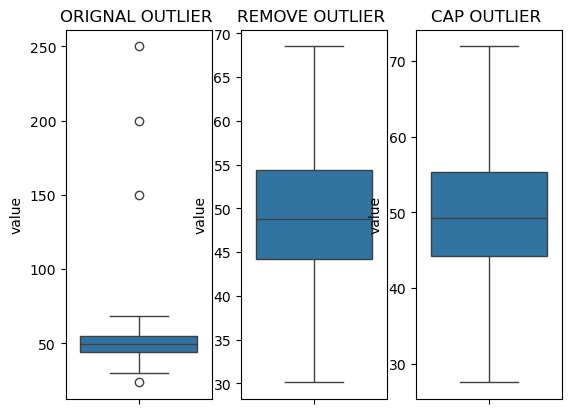

In [14]:
# VISUALIZATION

fig,axes=plt.subplots(1,3)
sns.boxplot(y=df["value"],ax=axes[0])
axes[0].set_title("ORIGNAL OUTLIER ")

sns.boxplot(y=remove_outlier["value"],ax=axes[1])
axes[1].set_title("REMOVE OUTLIER ")

sns.boxplot(y=df_cap["value"],ax=axes[2])
axes[2].set_title("CAP OUTLIER ")

plt.show()